<a href="https://colab.research.google.com/github/helenlu-vbs/NLP_LLM_for_Finance_and-Accounting_Research-Sheffield-/blob/main/001_use_LM_dictionary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Steps

This analysis compares the speech patterns of **Elon Musk** and **Jensen Huang** using the **Loughran-McDonald (LM) dictionary**.

1.  **Data Extraction**: Load data; define categories of sentiment; filtered the Q&A transcript to isolate turns belonging to each speaker.
2.  **Text Preprocessing**: Unified text to uppercase and removed non-alphabetical characters to match the LM dictionary.
3.  **Dictionary Matching**: Counted occurrences of tokens for 8 sentiment categories (Negative, Positive, Uncertainty, etc.).
4.  **Normalization**: Calculated 'Count per 1,000 words' to account for differences in total speech length.
5.  **Validation**: Verified results against the reference dataset.

In [1]:
# 1 import libraries and extract data
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

lm_dictionary_df = pd.read_csv('/content/001_LM_dictionary.csv', encoding='utf-8-sig', dtype=dtype_dict)
qna_df = pd.read_csv('/content/002_tesla_nvidia_2024_qna.csv')


# define categories
LM_CATEGORIES = ["Negative", "Positive", "Uncertainty", "Litigious", "Strong_Modal", "Weak_Modal", "Constraining", "Complexity"]
dtype_dict = {col: int for col in LM_CATEGORIES}
dtype_dict['Word'] = str



,Speaker,Category,Raw Count,Normalized Count (per 1000 words)
0,Elon Musk,Negative,73,8.032570
1,Elon Musk,Positive,131,14.414613
2,Elon Musk,Uncertainty,82,9.022887
3,Elon Musk,Litigious,12,1.320423
4,Elon Musk,Strong_Modal,70,7.702465
5,Elon Musk,Weak_Modal,37,4.071303
6,Elon Musk,Constraining,13,1.430458
7,Elon Musk,Complexity,7,0.770246
8,Jensen Huang,Negative,14,4.091175
9,Jensen Huang,Positive,49,14.319112


In [ ]:
# Prepare Lookup Dictionary (Uppercase)
up_lm_lookup = {str(row['Word']).upper(): {cat: row[cat] for cat in LM_CATEGORIES} for _, row in lm_dictionary_df.iterrows() if any(row[LM_CATEGORIES] != 0)}

# show top words in each category
category_samples = {}
for cat in LM_CATEGORIES:
    # Find words where this specific category has a non-zero value
    words_in_cat = [word for word, data in up_lm_lookup.items() if data[cat] != 0]
    # Store the first 10 words as a sample
    category_samples[cat] = words_in_cat[:10]

# Display the samples in a readable format
sample_df = pd.DataFrame.from_dict(category_samples, orient='index').transpose()
print("Sample Words per Category in LM Dictionary:")
display(sample_df)


In [ ]:
#Extract and Clean Speeches
def final_tokenize(text):
    return re.sub(r'[^A-Z\s]', ' ', str(text).upper()).split()

elon_text = ' '.join(qna_df[qna_df['speaker_name'] == 'Elon Musk']['turn_text'])
jensen_text = ' '.join(qna_df[qna_df['speaker_name'] == 'Jensen Huang']['turn_text'])

elon_tokens = final_tokenize(elon_text)
jensen_tokens = final_tokenize(jensen_text)

# show example speech


In [4]:
print("Elon Musk Cleaned Speech Sample (First 500 characters):")
print(" ".join(elon_tokens)[:500] + "...")

print("\n" + "="*50 + "\n")

print("Jensen Huang Cleaned Speech Sample (First 500 characters):")
print(" ".join(jensen_tokens)[:500] + "...")

Elon Musk Cleaned Speech Sample (First 500 characters):
WE I MEAN I WON T CERTAINLY SAY THINGS WITH THAT SHOULD BE TAKEN WITH A GRAIN OF SALT SINCE I M OFTEN OPTIMISTIC BUT I DON T WANT TO BLOW YOUR MIND BUT I M OFTEN OPTIMISTIC REGARDING TIME BUT OUR CURRENT SCHEDULE SHOWS THAT WE WILL START PRODUCTION TOWARDS THE END OF SOMETIME IN THE SECOND HALF THAT S JUST WHAT OUR CURRENT SCHEDULE SAYS THERE S A LOT OF NEW TECHNOLOGY LIKE A TREMENDOUS AMOUNT OF NEW REVOLUTIONARY MANUFACTURING TECHNOLOGY HERE IT S A HARD PROBLEM LIKE THERE ARE ENTIRE COMPANIES W...


Jensen Huang Cleaned Speech Sample (First 500 characters):
THANKS TOSHIYA LET S SEE THERE WERE QUESTIONS ONE MORE TIME FIRST QUESTION WAS OKAY YES WELL YOU KNOW WE GUIDE QUARTER AT A TIME BUT FUNDAMENTALLY THE CONDITIONS ARE EXCELLENT FOR CONTINUED GROWTH CALENDAR TO CALENDAR AND BEYOND AND LET ME TELL YOU WHY WE RE AT THE BEGINNING OF INDUSTRY WIDE TRANSITIONS AND BOTH OF THEM ARE INDUSTRY WIDE THE FIRST ONE IS A TRANSITION FROM GENE

In [6]:
# 3. Categorize and Normalize
def get_sentiment_counts(tokens, lookup, categories):
    counts = {cat: 0 for cat in categories}
    for token in tokens:
        if token in lookup:
            for cat in categories:
                if lookup[token][cat] != 0: counts[cat] += 1
    return counts

elon_raw = get_sentiment_counts(elon_tokens, up_lm_lookup, LM_CATEGORIES)
jensen_raw = get_sentiment_counts(jensen_tokens, up_lm_lookup, LM_CATEGORIES)

# Combine and Normalize
summary_list = []
for speaker, counts, total_w in [('Elon Musk', elon_raw, len(elon_tokens)), ('Jensen Huang', jensen_raw, len(jensen_tokens))]:
    for cat in LM_CATEGORIES:
        summary_list.append({
            'Speaker': speaker, 'Category': cat, 'Raw Count': counts[cat],
            'Normalized Count (per 1000 words)': (counts[cat] / total_w) * 1000
        })

final_summary_df = pd.DataFrame(summary_list)
display(final_summary_df.head(16))

,Speaker,Category,Raw Count,Normalized Count (per 1000 words)
0,Elon Musk,Negative,73,8.032570
1,Elon Musk,Positive,131,14.414613
2,Elon Musk,Uncertainty,82,9.022887
3,Elon Musk,Litigious,12,1.320423
4,Elon Musk,Strong_Modal,70,7.702465
5,Elon Musk,Weak_Modal,37,4.071303
6,Elon Musk,Constraining,13,1.430458
7,Elon Musk,Complexity,7,0.770246
8,Jensen Huang,Negative,14,4.091175
9,Jensen Huang,Positive,49,14.319112


In [5]:
# top words used by each person in each sentiment category
from collections import Counter

def get_top_hits(tokens, lookup, categories, top_n=5):
    hits = {cat: Counter() for cat in categories}
    for token in tokens:
        if token in lookup:
            for cat in categories:
                if lookup[token][cat] != 0:
                    hits[cat][token] += 1

    # Format as strings for display
    formatted_hits = {}
    for cat in categories:
        top_words = hits[cat].most_common(top_n)
        formatted_hits[cat] = ", ".join([f"{w} ({c})" for w, c in top_words])
    return formatted_hits

elon_hits = get_top_hits(elon_tokens, up_lm_lookup, LM_CATEGORIES)
jensen_hits = get_top_hits(jensen_tokens, up_lm_lookup, LM_CATEGORIES)

hits_df = pd.DataFrame([elon_hits, jensen_hits], index=['Elon Musk', 'Jensen Huang']).transpose()
print("Top Sentiment Word Hits (Word and Frequency):")
display(hits_df)

Top Sentiment Word Hits (Word and Frequency):


,Elon Musk,Jensen Huang
Negative,"DIFFICULT (6), WRONG (6), QUESTION (5), WORST ...","QUESTION (7), QUESTIONS (2), COMPLICATED (2), ..."
Positive,"GOOD (16), BETTER (15), GREAT (15), ABLE (14),...","BEST (10), INCREDIBLE (6), GOOD (3), BETTER (3..."
Uncertainty,"COULD (12), PROBABLY (10), MAYBE (8), BELIEVE ...","COULD (5), POSSIBLE (4), PROBABLY (3), BELIEVE..."
Litigious,"WHEREAS (4), REGULATORS (3), REGULATORY (2), M...","LAW (2), WHATEVER (2), REGULATORS (1), LEGAL (..."
Strong_Modal,"WILL (56), BEST (6), DEFINITELY (3), NEVER (3)...","WILL (18), BEST (10), ALWAYS (2), HIGHEST (1)"
Weak_Modal,"COULD (12), MAYBE (8), ALMOST (4), MIGHT (3), ...","COULD (5), POSSIBLE (4), ALMOST (2)"
Constraining,"LIMIT (3), CONSTRAINED (2), DEPENDING (2), REQ...","RESTRICTIONS (3), LIMIT (1), CONSTRAINTS (1), ..."
Complexity,"LICENSING (4), COMPLEX (3)","WORLDWIDE (1), GLOBAL (1)"


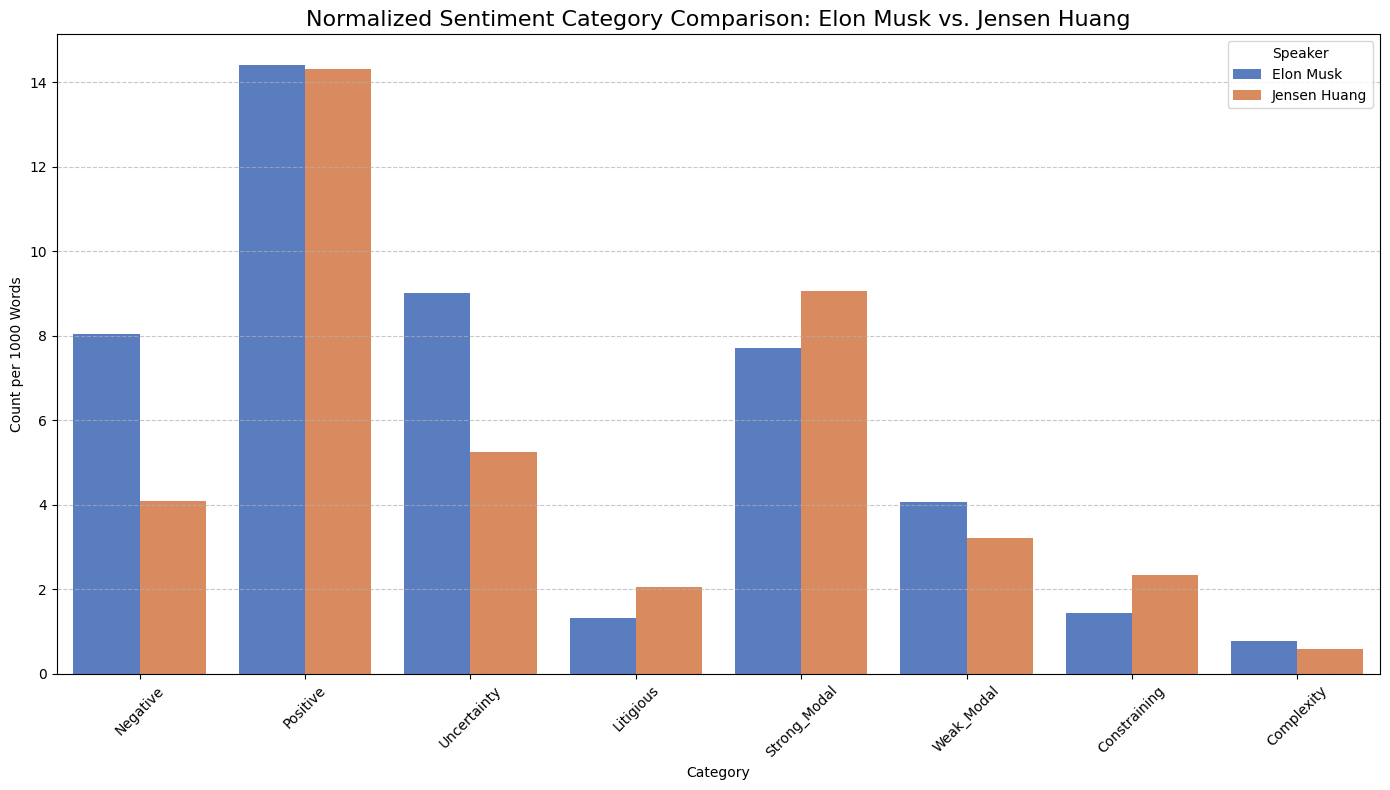

In [2]:
#Visualization
plt.figure(figsize=(14, 8))
sns.barplot(data=final_summary_df, x='Category', y='Normalized Count (per 1000 words)', hue='Speaker', palette='muted')
plt.title('Normalized Sentiment Category Comparison: Elon Musk vs. Jensen Huang', fontsize=16)
plt.ylabel('Count per 1000 Words')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()